## LTV prediction 

It's a **regression** problem (predicting a continuous dollar value), not classification like the last two. 

**Target:** predict a customer's `total_ltv` 

**Leakage check:** I can't use anything that's *part of* how LTV was calculated in my postgresql (obviously not `orders.total_amount` or `subscriptions.mrr` directly). I want to predict LTV from **early, predictive signals**, the same kind of things we'd know shortly after a customer signs up, before their full lifetime value has played out. 

"given what we know about a customer early on, can I predict how valuable they'll become?"

**Features (all knowable early/independently):**
- Acquisition channel, country, customer_type
- Early engagement: page_views, view_item_events, sessions (same browsing signals as propensity)
- CRM engagement
- Account age (as a control, not the target)

Check the attached sql file


In [1]:
# Imports, DB connection, load LTV prediction features

import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

query = """
WITH ecommerce_revenue AS (
    SELECT customer_id, SUM(total_amount) AS ecommerce_ltv
    FROM orders
    WHERE order_status = 'completed'
    GROUP BY customer_id
),
saas_revenue AS (
    SELECT customer_id,
        SUM(mrr * GREATEST(
            EXTRACT(YEAR FROM AGE(COALESCE(end_date, CURRENT_DATE), start_date)) * 12 +
            EXTRACT(MONTH FROM AGE(COALESCE(end_date, CURRENT_DATE), start_date)),
        1)) AS saas_ltv
    FROM subscriptions
    GROUP BY customer_id
)
SELECT
    c.customer_id,
    c.acquisition_channel,
    c.country,
    c.customer_type,
    EXTRACT(YEAR FROM AGE(CURRENT_DATE, c.signup_date)) * 12 +
    EXTRACT(MONTH FROM AGE(CURRENT_DATE, c.signup_date)) AS account_age_months,
    COALESCE(browse.page_views, 0) AS page_views,
    COALESCE(browse.view_item_events, 0) AS view_item_events,
    COALESCE(browse.distinct_sessions, 0) AS distinct_sessions,
    COALESCE(browse.mobile_session_pct, 0) AS mobile_session_pct,
    COALESCE(crm.total_sent, 0) AS crm_emails_sent,
    COALESCE(crm.total_opened, 0) AS crm_emails_opened,
    COALESCE(crm.total_clicked, 0) AS crm_emails_clicked,
    COALESCE(e.ecommerce_ltv, 0) + COALESCE(s.saas_ltv, 0) AS total_ltv
FROM customers c
LEFT JOIN ecommerce_revenue e ON c.customer_id = e.customer_id
LEFT JOIN saas_revenue s ON c.customer_id = s.customer_id
LEFT JOIN (
    SELECT customer_id,
        COUNT(*) FILTER (WHERE event_name = 'page_view') AS page_views,
        COUNT(*) FILTER (WHERE event_name = 'view_item') AS view_item_events,
        COUNT(DISTINCT session_id) AS distinct_sessions,
        ROUND(100.0 * COUNT(*) FILTER (WHERE device_category = 'mobile') / COUNT(*), 1) AS mobile_session_pct
    FROM ga4_events
    WHERE event_name IN ('page_view', 'view_item')
    GROUP BY customer_id
) browse ON c.customer_id = browse.customer_id
LEFT JOIN (
    SELECT customer_id, COUNT(*) AS total_sent,
        SUM(opened::int) AS total_opened, SUM(clicked::int) AS total_clicked
    FROM crm_engagement
    GROUP BY customer_id
) crm ON c.customer_id = crm.customer_id;
"""

ltv_features = pd.read_sql(query, engine)
print(f"Loaded {len(ltv_features)} rows.")
print(f"\nLTV stats:\n{ltv_features['total_ltv'].describe()}")
ltv_features.head()

Loaded 20000 rows.

LTV stats:
count    20000.000000
mean       216.921004
std        427.713217
min          0.000000
25%          0.000000
50%         45.000000
75%        258.710000
max       4536.360000
Name: total_ltv, dtype: float64


,customer_id,acquisition_channel,country,customer_type,account_age_months,page_views,view_item_events,distinct_sessions,mobile_session_pct,crm_emails_sent,crm_emails_opened,crm_emails_clicked,total_ltv
0,1,Google,United Kingdom,saas,5.0,2,1,2,0.0,6,3,1,75.0
1,2,Organic,Nigeria,both,13.0,11,5,11,43.8,12,6,0,195.0
2,3,Google,Canada,ecommerce,20.0,3,3,3,66.7,14,4,0,0.0
3,4,Organic,Germany,saas,6.0,2,2,2,50.0,12,6,2,270.0
4,5,Google,United States,ecommerce,14.0,5,2,5,28.6,12,1,1,332.5


This distribution tells me something important before I model anything: highly right-skewed, with a median of $45 but a mean of $217 and a max of $4,536, meaning a small number of high-value customers pull the average way up. And the 25th percentile being exactly $0 means at least a quarter of customers have generated no measurable LTV at all (likely those who signed up but never purchased or subscribed).

Why this matters for modeling: skewed targets like this are genuinely tricky for regression models, a few extreme high-LTV customers can disproportionately influence the model's errors (since squared-error-based metrics like RMSE penalize big misses heavily). A common, standard technique here is to train the model on the log of LTV instead of raw LTV, which compresses that skew and often produces a much better-behaved model, then convert predictions back at the end.

In [2]:
# Log-transform target, encode categoricals, train/test split

import numpy as np
from sklearn.model_selection import train_test_split

# log1p(x) = log(1 + x) — the "+1" avoids errors on customers with
# exactly $0 LTV, since log(0) is undefined.
ltv_features['log_ltv'] = np.log1p(ltv_features['total_ltv'])

ltv_features_encoded = pd.get_dummies(
    ltv_features,
    columns=['acquisition_channel', 'country', 'customer_type'],
    drop_first=True
)

# Exclude customer_id, and BOTH target versions (raw and log) from features
feature_columns = [col for col in ltv_features_encoded.columns 
                   if col not in ['customer_id', 'total_ltv', 'log_ltv']]

X = ltv_features_encoded[feature_columns]
y_log = ltv_features_encoded['log_ltv']       # what we'll train on
y_raw = ltv_features_encoded['total_ltv']     # keep around for final interpretation

# No stratify here — that's a classification-only concept, since there's
# no fixed set of classes to balance for a continuous target.
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Also keep the raw (non-log) test values, matched to the same split,
# so we can convert predictions back and evaluate in real dollar terms later.
_, _, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows")
print(f"Total features: {len(feature_columns)}")

Training set: 16000 rows
Test set: 4000 rows
Total features: 20


In [3]:
# Training Linear Regression, Random Forest, and Gradient Boosting
# on the log-transformed target, then compare all three.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ltv_model_linear = LinearRegression()
ltv_model_linear.fit(X_train, y_train_log)

ltv_model_rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
ltv_model_rf.fit(X_train, y_train_log)

ltv_model_gbm = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
ltv_model_gbm.fit(X_train, y_train_log)

models = {
    'Linear Regression': ltv_model_linear,
    'Random Forest': ltv_model_rf,
    'Gradient Boosting': ltv_model_gbm
}

print(f"{'Model':<20} {'RMSE ($)':<12} {'MAE ($)':<12} {'R²':<8}")
print("-" * 55)

for name, model in models.items():
    log_predictions = model.predict(X_test)
    # Convert predictions back from log scale to real dollars.
    # expm1 is the exact inverse of log1p (undoes the "+1" shift too).
    dollar_predictions = np.expm1(log_predictions)
    
    rmse = np.sqrt(mean_squared_error(y_test_raw, dollar_predictions))
    mae = mean_absolute_error(y_test_raw, dollar_predictions)
    r2 = r2_score(y_test_raw, dollar_predictions)
    
    print(f"{name:<20} {rmse:<12.2f} {mae:<12.2f} {r2:<8.3f}")

Model                RMSE ($)     MAE ($)      R²      
-------------------------------------------------------
Linear Regression    390.18       159.67       0.104   
Random Forest        359.19       148.41       0.241   
Gradient Boosting    362.63       149.50       0.226   


**Random Forest wins** on all three metrics, though Gradient Boosting is close behind: lowest RMSE ($359 vs $390 for linear), lowest MAE ($148), and highest R² (0.241). Linear Regression is clearly the weakest of the three.

**An R² of 0.24 is genuinely modest.** That means my best model only explains about **24% of the variation** in customer LTV, the other 76% is driven by factors I simply don't have in my feature set. 

In [4]:
# Permutation importance on my best model (Random Forest)

from sklearn.inspection import permutation_importance

permutation_results_ltv = permutation_importance(
    ltv_model_rf, X_test, y_test_log,
    n_repeats=10,
    random_state=42,
    scoring='r2'   # measure drop in R² this time, since this is regression not classification
)

permutation_importance_ltv = pd.Series(
    permutation_results_ltv.importances_mean, index=feature_columns
).sort_values(ascending=False)

print("Permutation importance (drop in R² when feature is shuffled):")
print(permutation_importance_ltv)

Permutation importance (drop in R² when feature is shuffled):
customer_type_ecommerce         1.260383
view_item_events                0.064413
account_age_months              0.059580
mobile_session_pct              0.000572
crm_emails_clicked              0.000519
crm_emails_sent                 0.000346
acquisition_channel_Google      0.000317
acquisition_channel_Organic     0.000280
country_India                   0.000226
crm_emails_opened               0.000071
customer_type_saas              0.000042
country_United Kingdom         -0.000011
country_Germany                -0.000046
acquisition_channel_Referral   -0.000108
acquisition_channel_Meta       -0.000158
distinct_sessions              -0.000248
acquisition_channel_Email      -0.000257
page_views                     -0.000324
country_United States          -0.000386
country_Nigeria                -0.001047
dtype: float64


**`customer_type_ecommerce`: 1.26 - larger than the model's entire R² (0.24).** That might look like an error, but it's mathematically valid: permutation importance measures the *drop* in R², and shuffling a truly critical feature can push R² deeply negative (worse than just guessing the average), so a "drop" can exceed the original score. This isn't a bug, it's a sign this feature is extraordinarily load-bearing for the model.

**Why does `customer_type` matter this much, and is it legitimate (not leakage)?** Looking at what `customer_type` structurally means in my data: `'ecommerce'` customers can *only* ever generate `ecommerce_ltv` (they have no subscription), `'saas'` customers can *only* generate `saas_ltv`, and `'both'` customers draw from two revenue streams. So `customer_type` isn't just *correlated* with LTV, it directly determines **which revenue streams are even possible** for that customer. Critically, this is known **at signup**, completely independent of any future behavior, so it passes my leakage test cleanly, unlike `active_days` or `customer_type` in the earlier churn/propensity models where the concern was circularity with the *outcome itself*.

**The next two, both legitimate and expected:**
- `view_item_events` (0.064) - consistent with propensity: browsing intent correlates with eventual value, though modestly here.
- `account_age_months` (0.060) - makes sense: customers who've been around longer have simply had more *time* to accumulate value.

**Everything else** (acquisition channel, country, CRM engagement) - negligible or slightly negative, same pattern as before: essentially noise in this model.

## The final conclusion

> **Customer type (ecommerce/SaaS/both) overwhelmingly drives predicted LTV, a structural feature reflecting which revenue streams a customer can access, followed by modest, genuine contributions from browsing intent and account age. Marketing/acquisition-level signals (channel, country, CRM engagement) show no meaningful relationship with lifetime value in this dataset.**

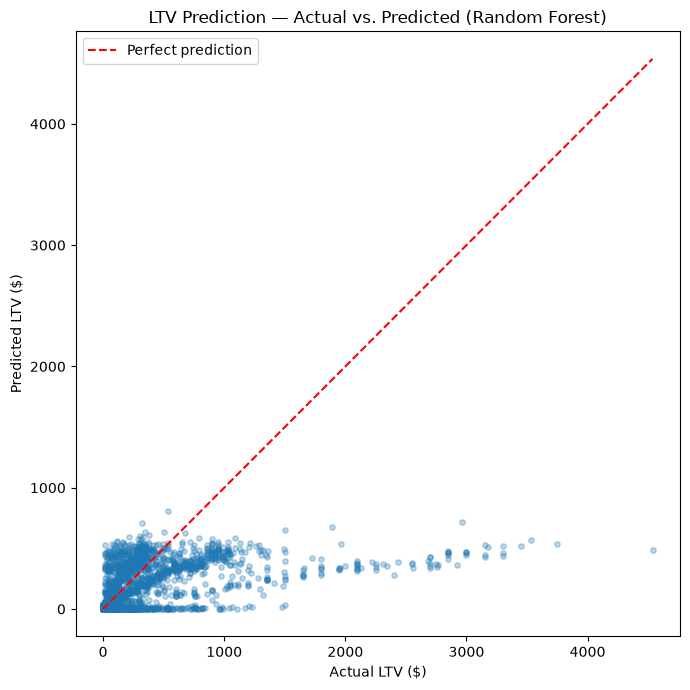

In [7]:
# Actual vs. Predicted LTV scatter plot (Random Forest)

rf_log_predictions = ltv_model_rf.predict(X_test)
rf_dollar_predictions = np.expm1(rf_log_predictions)
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test_raw, rf_dollar_predictions, alpha=0.3, s=15)

# A perfect model would have every point exactly on this diagonal line
max_val = max(y_test_raw.max(), rf_dollar_predictions.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual LTV ($)')
plt.ylabel('Predicted LTV ($)')
plt.title('LTV Prediction — Actual vs. Predicted (Random Forest)')
plt.legend()
plt.tight_layout()
plt.show()

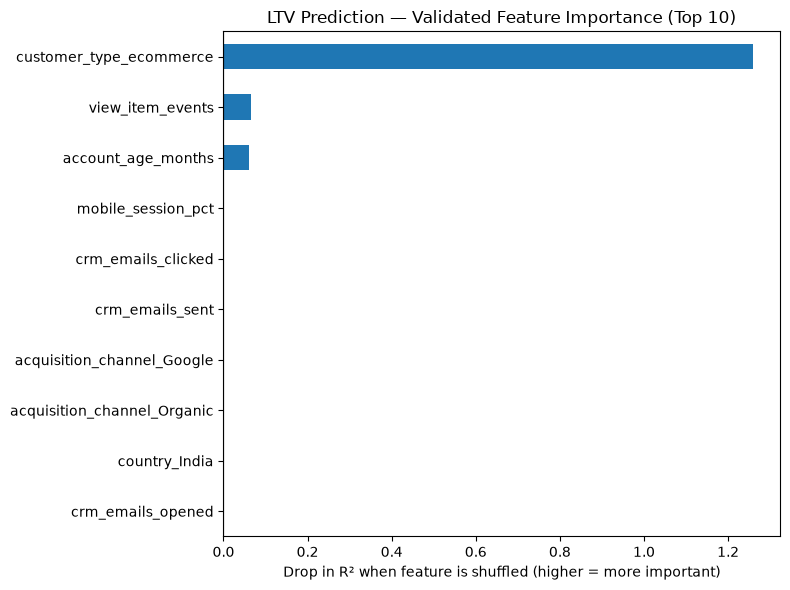

In [8]:
# Validated feature importance (permutation-based)

plt.figure(figsize=(8, 6))
permutation_importance_ltv.sort_values().tail(10).plot(kind='barh', color='#1f77b4')
plt.title('LTV Prediction — Validated Feature Importance (Top 10)')
plt.xlabel('Drop in R² when feature is shuffled (higher = more important)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**The scatter plot tells an important story:** the model's predictions cluster in a fairly narrow band (mostly $0-700) regardless of how high the *actual* LTV climbs (up to $4,500+), the points fan out increasingly far *below* the red "perfect" line as actual LTV grows. This means: **my model is decent at distinguishing low-value from moderate-value customers, but it systematically underpredicts the highest-value customers.** That's a very real, common regression pattern, models trained this way tend to be conservative/regress toward the average, especially for rare high-value outliers where there's less data to learn from. That's a more nuanced, honest insight than the R²=0.

**The feature importance chart** makes the earlier point viscerally clear - `customer_type_ecommerce` isn't just "the top feature," it's in a completely different league from everything else, which visually reinforces that this is a structural/eligibility signal, not a subtle behavioral pattern.

In [9]:
import joblib
joblib.dump(ltv_model_rf, 'ltv_model.pkl')
joblib.dump(feature_columns, 'ltv_model_features.pkl')

['ltv_model_features.pkl']